<a href="https://colab.research.google.com/github/RegiRezende/MathCode/blob/Python_codes/REDE_NEURAL_1_Classif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
# ==============================================
#           REDE NEURAL DO ZERO
# ==============================================
# Este modelo é uma rede feedforward com uma camada oculta,
# para a classificação multiclasse usando função de ativação softmax
# na camada de saída para transformar os resultados brutos em probabilidades,
# Cross-Entropy (Entropia Cruzada) como função de perda para medir o erro.

In [62]:
# Importando bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import pandas as pd
import pickle

# numpy: biblioteca para operações matemáticas e matrizes (base da maioria das redes neurais)
# matplotlib: biblioteca para criar gráficos e visualizações
# sklearn.datasets: contém datasets prontos para testar modelos
# pandas: biblioteca para manipulação de dados (tabelas)
# pickle: biblioteca para salvar e carregar objetos Python (útil para salvar modelos treinados)

In [63]:
# Configurações de visualização para os gráfico
plt.rcParams['figure.figsize']=(10,8)  # Define o tamanho padrão das figuras (10 polegadas de largura, 8 de altura)
plt.style.use('dark_background')       # Usa tema escuro para os gráficos



1.   Dataset




In [64]:
# ==============================================
# PARTE 1: PRIMEIRO DATASET - "make_moons"
# ==============================================

# make_moons gera um dataset em formato de duas luas crescentes
# É um problema clássico para testar redes neurais porque não é linearmente separável
# não dá para separar as classes a partir de uma linha reta

x, y = datasets.make_moons(n_samples=500, noise=0.05)

visualizando os valores dos dados

In [65]:
# O que são x e y?
# x: matriz com as características (features) dos dados - neste caso, coordenadas (x1, x2)
# y: vetor com os rótulos (labels) - 0 ou 1 indicando a qual lua cada ponto pertence

# Visualizando informações sobre os dados
print (f'{x.shape = }, {y.shape =}') # f-string com = mostra o nome da variável e seu valor

# x.shape = (500, 2) -> 500 amostras, 2 características (coordenadas x e y)
# y.shape = (500,) -> 500 rótulos

x.shape = (500, 2), y.shape =(500,)


In [66]:
# Criando uma tabela para visualizar os primeiros dados
# pd.DataFrame cria uma tabela estilo Excel
# x[:,0] pega TODAS as linhas (:) da coluna 0 (primeira coordenada)
# x[:,1] pega TODAS as linhas da coluna 1 (segunda coordenada)
pd.DataFrame({'x_1': x[:,0], 'x_2': x[:,1], 'y': y})

,x_1,x_2,y
0,0.709830,-0.501719,1
1,1.996753,0.178510,1
2,1.701868,-0.275974,1
3,-0.995302,0.193433,0
4,1.193102,-0.500193,1
...,...,...,...
495,-0.976416,0.062191,0
496,1.704281,-0.159129,1
497,-1.041607,-0.027748,0
498,0.054734,1.016572,0


Tendo duas entradas x1 e x2, tentar prever se este valor pertence à classe y=0 ou y=1

In [67]:
# np.unique encontra os valores únicos em y e conta quantas vezes cada um aparece
unique = np.unique(y, return_counts= True)        # return_counts=True faz ele também retornar as contagens
for label, qt_label in zip(unique[0], unique[1]): # zip junta duas listas em pares
  print(f'Label:{label}\t Counts {qt_label}')

  # Isso mostra que temos aproximadamente 250 amostras de cada classe (0 e 1)

Label:0	 Counts 250
Label:1	 Counts 250


os valores y ou sao 0 ou sao 1

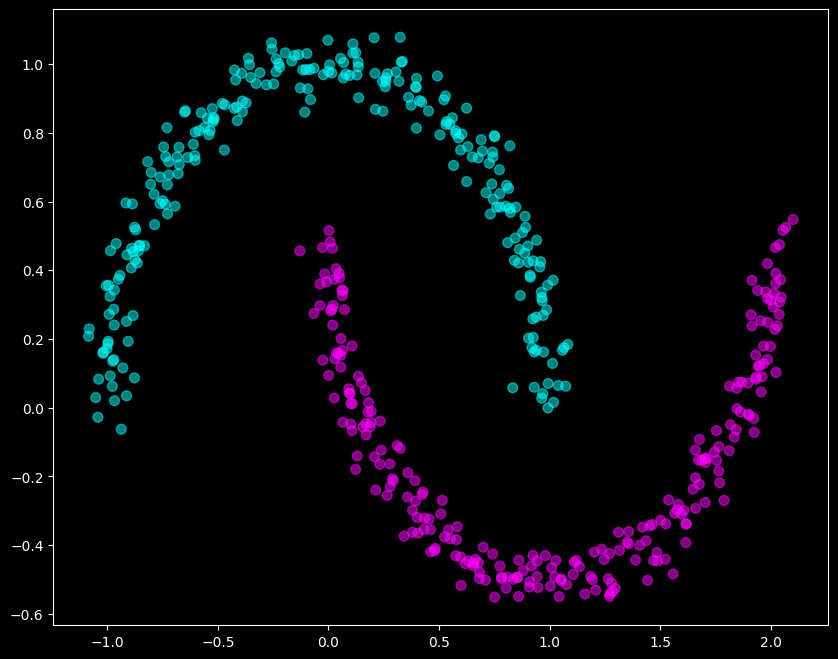

In [68]:
# Visualizando os dados em um gráfico de dispersão
# plt.scatter cria um gráfico de pontos
# c=y significa que a cor de cada ponto será determinada pelo seu rótulo (0 ou 1)
# s=50 é o tamanho dos pontos
# alpha=0.5 é a transparência (0=invisível, 1=sólido)
# cmap='cool' é o mapa de cores (esquema de cores legal)
plt.scatter(x[:,0], x[:,1], c = y, s =50, alpha = 0.5, cmap ='cool')

# Modelo

- Inicializaçao de pesos e bias
- Construir uma função para o feedforward
- Cálculo da perda
- Backpropagation
- Fit
usando classes

In [69]:
hidden_neurons = 10
output_neurons = 2
learning_rate = 0.01
epochs = 30

In [70]:
# @title
model = NnModel(x, y, hidden_neurons=hidden_neurons, output_neurons=output_neurons)     # criando o modelo
result = model.fit(epochs, learning_rate)                                               #treino

Epoch: [3] / 30  Accuracy: 0.500  Loss: 0.000000
Epoch: [6] / 30  Accuracy: 0.734  Loss: 0.000011
Epoch: [9] / 30  Accuracy: 0.876  Loss: 0.000006
Epoch: [12] / 30  Accuracy: 0.728  Loss: 0.000000
Epoch: [15] / 30  Accuracy: 0.888  Loss: 0.000000
Epoch: [18] / 30  Accuracy: 0.726  Loss: 0.000000
Epoch: [21] / 30  Accuracy: 0.892  Loss: 0.000000
Epoch: [24] / 30  Accuracy: 0.832  Loss: 0.000000
Epoch: [27] / 30  Accuracy: 0.900  Loss: 0.000000
Epoch: [30] / 30  Accuracy: 0.962  Loss: 0.000000


# Testes e Resultados

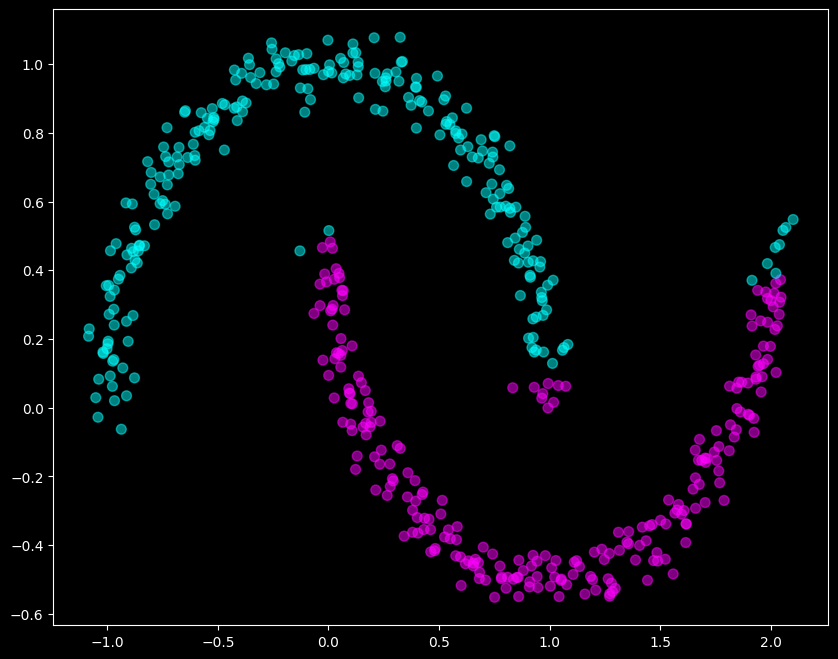

In [71]:
# Cria um gráfico de dispersão (scatter plot) dos dados após a classificação da rede neural
# x[:,0] -> valores da primeira característica (eixo x)
# x[:,1] -> valores da segunda característica (eixo y)
# c = result -> define a cor de cada ponto de acordo com a classe prevista pelo modelo
# s = 50 -> tamanho dos pontos no gráfico
# alpha = 0.5 -> transparência dos pontos (0 = totalmente transparente, 1 = totalmente opaco)
# cmap = 'cool' -> mapa de cores usado para diferenciar as classes

plt.scatter(x[:,0], x[:,1], c = result, s =50, alpha = 0.5, cmap ='cool')

# Cluster Dataset

In [85]:
# Gera um dataset sintético de clusters usando a função make_blobs do sklearn
# n_samples = 400 -> número total de pontos (amostras) gerados
# n_features = 2 -> número de características de cada ponto (dimensão do dado: x1 e x2)
# centers = 4 -> número de centros (clusters/classes) que serão gerados
# random_state = 10 -> fixa a semente aleatória para reproduzir sempre o mesmo dataset
# cluster_std = 0.9 -> desvio padrão dos pontos ao redor do centro do cluster (define o quão espalhados eles ficam)
# shuffle = True -> embaralha aleatoriamente a ordem das amostras geradas
 # Cluster std é o desvio padrão dos pontos dentro do cluster, quanto estao espalhados
x_, y_ = datasets.make_blobs(n_samples = 400, n_features = 2, centers = 4, random_state = 10, cluster_std =0.9, shuffle = True)


In [73]:
x_.shape, y_.shape       # 400 linhas por 2 colunas no x e 400 linhas do y

((400, 2), (400,))

In [74]:
np.unique(y_, return_counts = True)    # retorna quais são as classes 4 classes 0, 1, 2, 3 (com 100 observaçoes de cada uma), definidas acima como centers. O que queremos prever: Dado um ponto, à qual classe ele pertence?

(array([0, 1, 2, 3]), array([100, 100, 100, 100]))

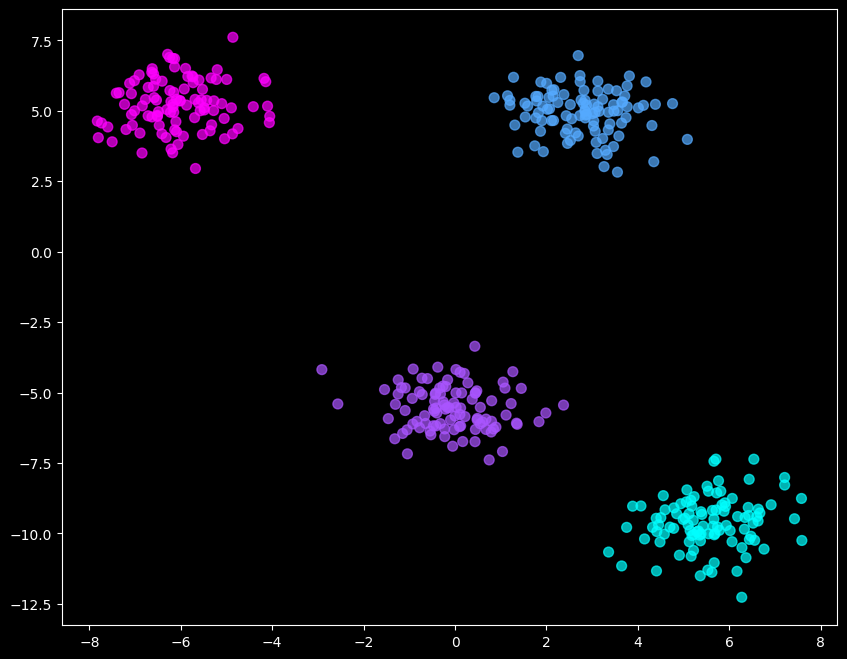

In [75]:
#Cada cor representa uma classe diferente (0, 1, 2 ou 3),
# facilitando observar como os pontos estão agrupados no espaço bidimensional.
plt.scatter(x_[:,0], x_[:,1], c = y_, s =50, alpha = 0.7, cmap ='cool')

In [87]:
 # Definição dos principais hiperparâmetros da rede neural
hidden_neurons =50      # define a capacidade da rede de aprender padrões mais complexos.
output_neurons = 4      # porque o dataset possui 4 classes (4 clusters).
learning_rate = 0.0015  # controla a velocidade de aprendizado da rede.
epochs = 1000           # o modelo será treinado 1000 vezes sobre todo o conjunto de dados.

In [88]:
model = NnModel(x_, y_, hidden_neurons=hidden_neurons, output_neurons=output_neurons)     # criando o modelo
result = model.fit(epochs, learning_rate)                                               #treino

Epoch: [100] / 1000  Accuracy: 0.998  Loss: 0.000001
Epoch: [200] / 1000  Accuracy: 0.998  Loss: 0.000000
Epoch: [300] / 1000  Accuracy: 0.998  Loss: 0.000000
Epoch: [400] / 1000  Accuracy: 0.998  Loss: 0.000000
Epoch: [500] / 1000  Accuracy: 0.998  Loss: 0.000000
Epoch: [600] / 1000  Accuracy: 0.998  Loss: 0.000000
Epoch: [700] / 1000  Accuracy: 1.000  Loss: 0.000000
Epoch: [800] / 1000  Accuracy: 1.000  Loss: 0.000000
Epoch: [900] / 1000  Accuracy: 1.000  Loss: 0.000000
Epoch: [1000] / 1000  Accuracy: 1.000  Loss: 0.000000


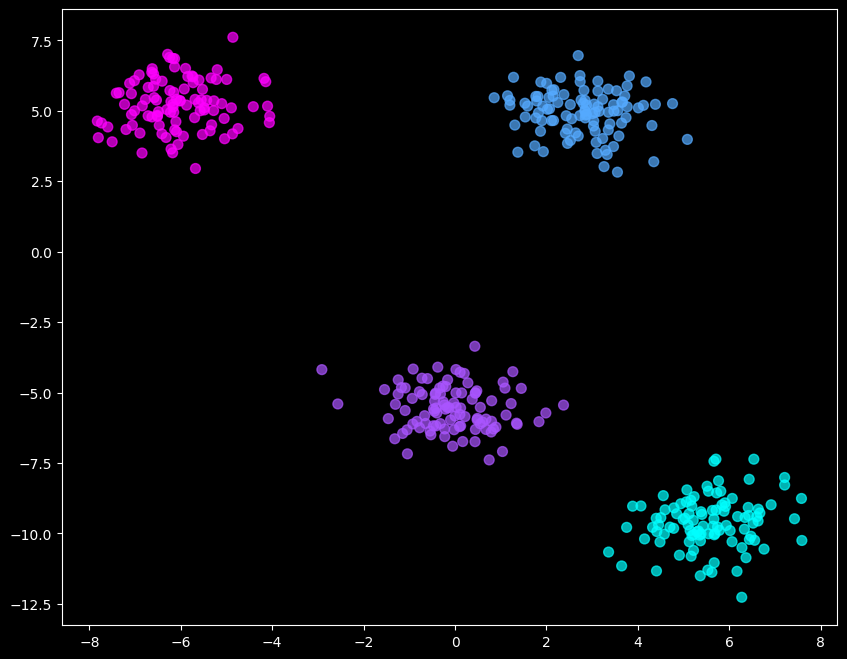

In [78]:
# com esta configuraçao houve 100% acertos
plt.scatter(x_[:,0], x_[:,1], c = result , s =50, alpha = 0.7, cmap ='cool')

# 3D

In [79]:
 # Repete o procedimento anterior para os dados gerados - 3D
 x_, y_ = datasets.make_blobs(n_samples = 400, n_features = 3, centers = 4, random_state = 50, cluster_std =0.9, shuffle = True)

In [80]:
# Mostra as dimensões (formato) dos dados gerados
# x_.shape -> retorna (número de amostras, número de características)
# y_.shape -> retorna (número de rótulos/classes correspondentes às amostras)
# Neste caso esperado: x_ (400, 3) porque há 400 pontos com 3 variáveis (x1, x2, x3)
# e y_ (400,) porque existe um rótulo para cada ponto
x_.shape, y_.shape

((400, 3), (400,))

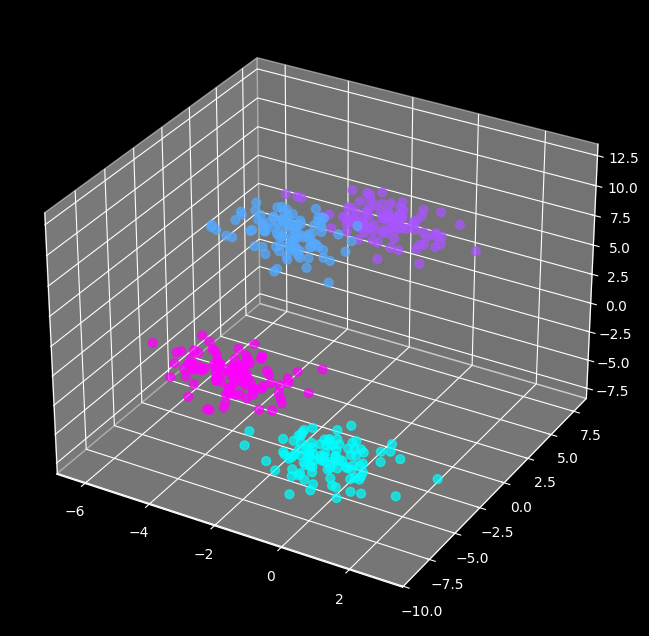

In [81]:
# Criando um gráfico de dispersão em 3D
# para visualizar os 4 clusters do dataset tridimensional.
# Cada ponto representa uma amostra e a cor indica a qual classe (cluster) ela pertence,

ax = plt.axes(projection = '3d')
ax.scatter(x_[:,0], x_[:,1], x_[:,2], c = y_, s =40, alpha = 0.7, cmap ='cool')

# Modelo 3D

In [89]:
# Cria uma instância da rede neural para o dataset tridimensional
# x_ -> matriz com as características de entrada (x1, x2, x3)
# y_ -> vetor com os rótulos das classes (clusters)
# hidden_neurons = 10 -> número de neurônios na camada oculta
# output_neurons = output_neurons -> número de neurônios na camada de saída (igual ao número de classes)

modelo_3D = NnModel(x_, y_, hidden_neurons=10, output_neurons=output_neurons)         # criando o modelo
resultado_3D = modelo_3D.fit(40, 0.001)                                               #treino

Epoch: [4] / 40  Accuracy: 0.985  Loss: 0.000606
Epoch: [8] / 40  Accuracy: 0.990  Loss: 0.000260
Epoch: [12] / 40  Accuracy: 0.990  Loss: 0.000167
Epoch: [16] / 40  Accuracy: 0.990  Loss: 0.000124
Epoch: [20] / 40  Accuracy: 0.990  Loss: 0.000098
Epoch: [24] / 40  Accuracy: 0.990  Loss: 0.000081
Epoch: [28] / 40  Accuracy: 0.990  Loss: 0.000069
Epoch: [32] / 40  Accuracy: 0.990  Loss: 0.000061
Epoch: [36] / 40  Accuracy: 0.990  Loss: 0.000054
Epoch: [40] / 40  Accuracy: 0.990  Loss: 0.000048


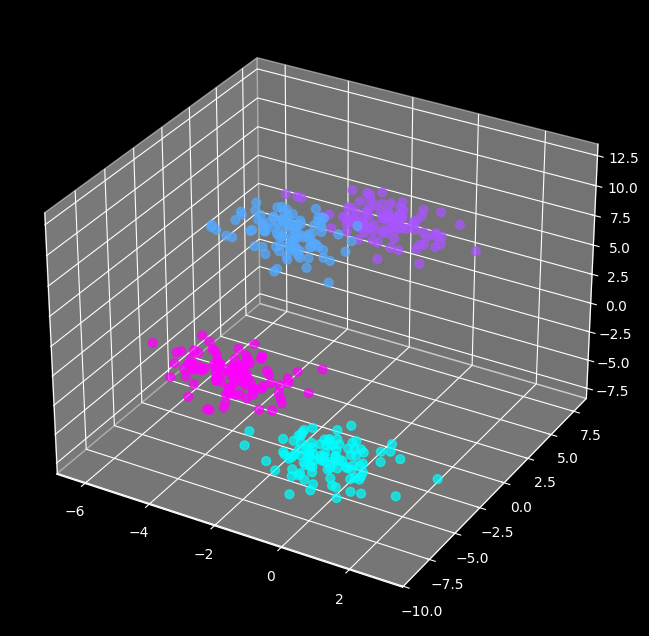

In [83]:
# Cria um sistema de eixos para um gráfico tridimensional (3D)
ax = plt.axes(projection = '3d')

# Plota um gráfico de dispersão 3D com os resultados da classificação da rede neural
# x_[:,0] -> valores da primeira característica (eixo x)
# x_[:,1] -> valores da segunda característica (eixo y)
# x_[:,2] -> valores da terceira característica (eixo z)
# c = resultado_3D -> define a cor de cada ponto de acordo com a classe prevista pelo modelo
# s = 40 -> tamanho dos pontos no gráfico
# alpha = 0.7 -> nível de transparência dos pontos
# cmap = 'cool' -> mapa de cores usado para diferenciar as classes previstas
ax.scatter(x_[:,0], x_[:,1], x_[:,2], c = resultado_3D, s =40, alpha = 0.7, cmap ='cool')

Esse último gráfico mostra como a rede neural classificou os pontos no espaço tridimensional.
Cada ponto representa uma amostra do dataset e a cor indica a classe prevista (resultado_3D), permitindo comparar visualmente se os clusters foram corretamente identificados pelo modelo.
Diferente do gráfico anterior, em que as cores representavam as classes reais,
aqui as cores representam as classes previstas pelo modelo (resultado_3D).
Isso permite comparar visualmente se a rede neural classificou corretamente os pontos.